In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pydeck.data_utils.viewport_helpers import k_nearest_neighbors
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report , confusion_matrix

from LogisticRegHyperparameterTunning.LogisticregressionandHyperparameterTunning import grid_search


In [2]:
print("Downloading the dataset...")
data=fetch_openml(name='diabetes',version=1 ,as_frame=True,parser='auto')
df=data.frame

In [3]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


In [4]:
df['class']=df['class'].map({'tested_positive' : 1 , 'tested_negative' : 0} )


In [10]:
df.isnull().sum()


preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [11]:
df.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [15]:
for col in df.columns:
    zero_counts=(df[col] ==0).sum()
    zero_percentage= (zero_counts / len(df[col])) * 100
    print(f"{col} :{zero_counts}   %{zero_percentage:.2f}")

preg :111   %14.45
plas :5   %0.65
pres :35   %4.56
skin :227   %29.56
insu :374   %48.70
mass :11   %1.43
pedi :0   %0.00
age :0   %0.00
class :500   %65.10


In [16]:
#there is a lot of 0 (its mean missing values)

In [17]:
columns_change=["plas","pres","skin","insu","mass"]

In [18]:
for col in columns_change:
    median_values= df[df[col]!=0][col].median()
    print(median_values)

117.0
72.0
29.0
125.0
32.3


In [19]:
for col in columns_change:
    median_values= df[df[col]!=0][col].median()
    df[col] = df[col].replace(0,median_values)


In [20]:
df.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


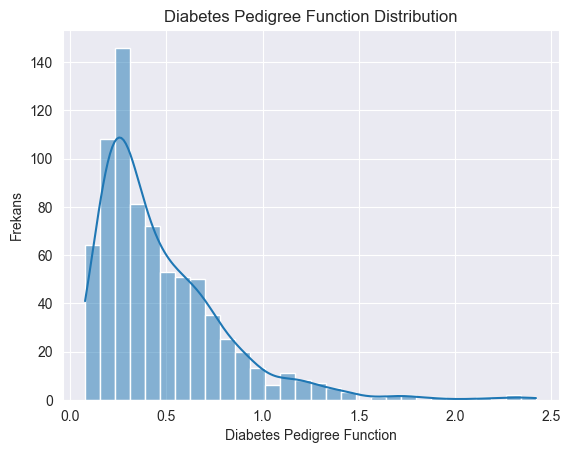

In [24]:
sns.histplot(df['pedi'], bins=30, kde=True)
plt.title('Diabetes Pedigree Function Distribution')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Frekans')
plt.show()

In [21]:
X=df.drop('class', axis=1)
y=df['class']

In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25 , random_state=15)

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
base=DecisionTreeClassifier(max_depth=3,random_state=42)
ada=AdaBoostClassifier(estimator=base)

In [116]:
params={
    'n_estimators' : [50 ,100,200,400,500],
    'learning_rate' : [0.01,0.1,1,2,5,10,100]
}

In [117]:
grid_search=GridSearchCV(estimator=ada,param_grid=params,n_jobs=-1,cv=5,scoring='accuracy')

In [118]:
grid_search.fit(X_train,y_train)

,estimator,AdaBoostClass...dom_state=42))
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [119]:
print("----------Best params--------")
print(grid_search.best_params_)


----------Best params--------
{'learning_rate': 0.01, 'n_estimators': 200}


In [120]:
y_pred=grid_search.predict(X_test)

In [121]:
print("----------accuracy score-----------")
print(accuracy_score(y_test,y_pred))

----------accuracy score-----------
0.7395833333333334


In [85]:
print(confusion_matrix(y_test,y_pred))

[[107  22]
 [ 28  35]]


In [75]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       129
           1       0.61      0.54      0.57        63

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.69       192
weighted avg       0.73      0.73      0.73       192



In [122]:
#Lets try another algorithm

0.7291666666666666
